<a href="https://colab.research.google.com/github/gunavathibaskaran170/AI-project-/blob/main/Handling_Missing_values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv('/content/drive/MyDrive/DATASET /preprocessing_dataset.csv')
df.head()


,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [6]:
df1=df.copy()# before doing any operation
df2=df.copy()
df3=df.copy()

# **Find the missing Values -info(),describe(),isnull(),isna()**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [8]:
df.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [9]:
df.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0


# VISUALIZATION- TO FIND THE MISSING VALUES THROUGH THE PACKAGE CALLED **missingno**

<Axes: >

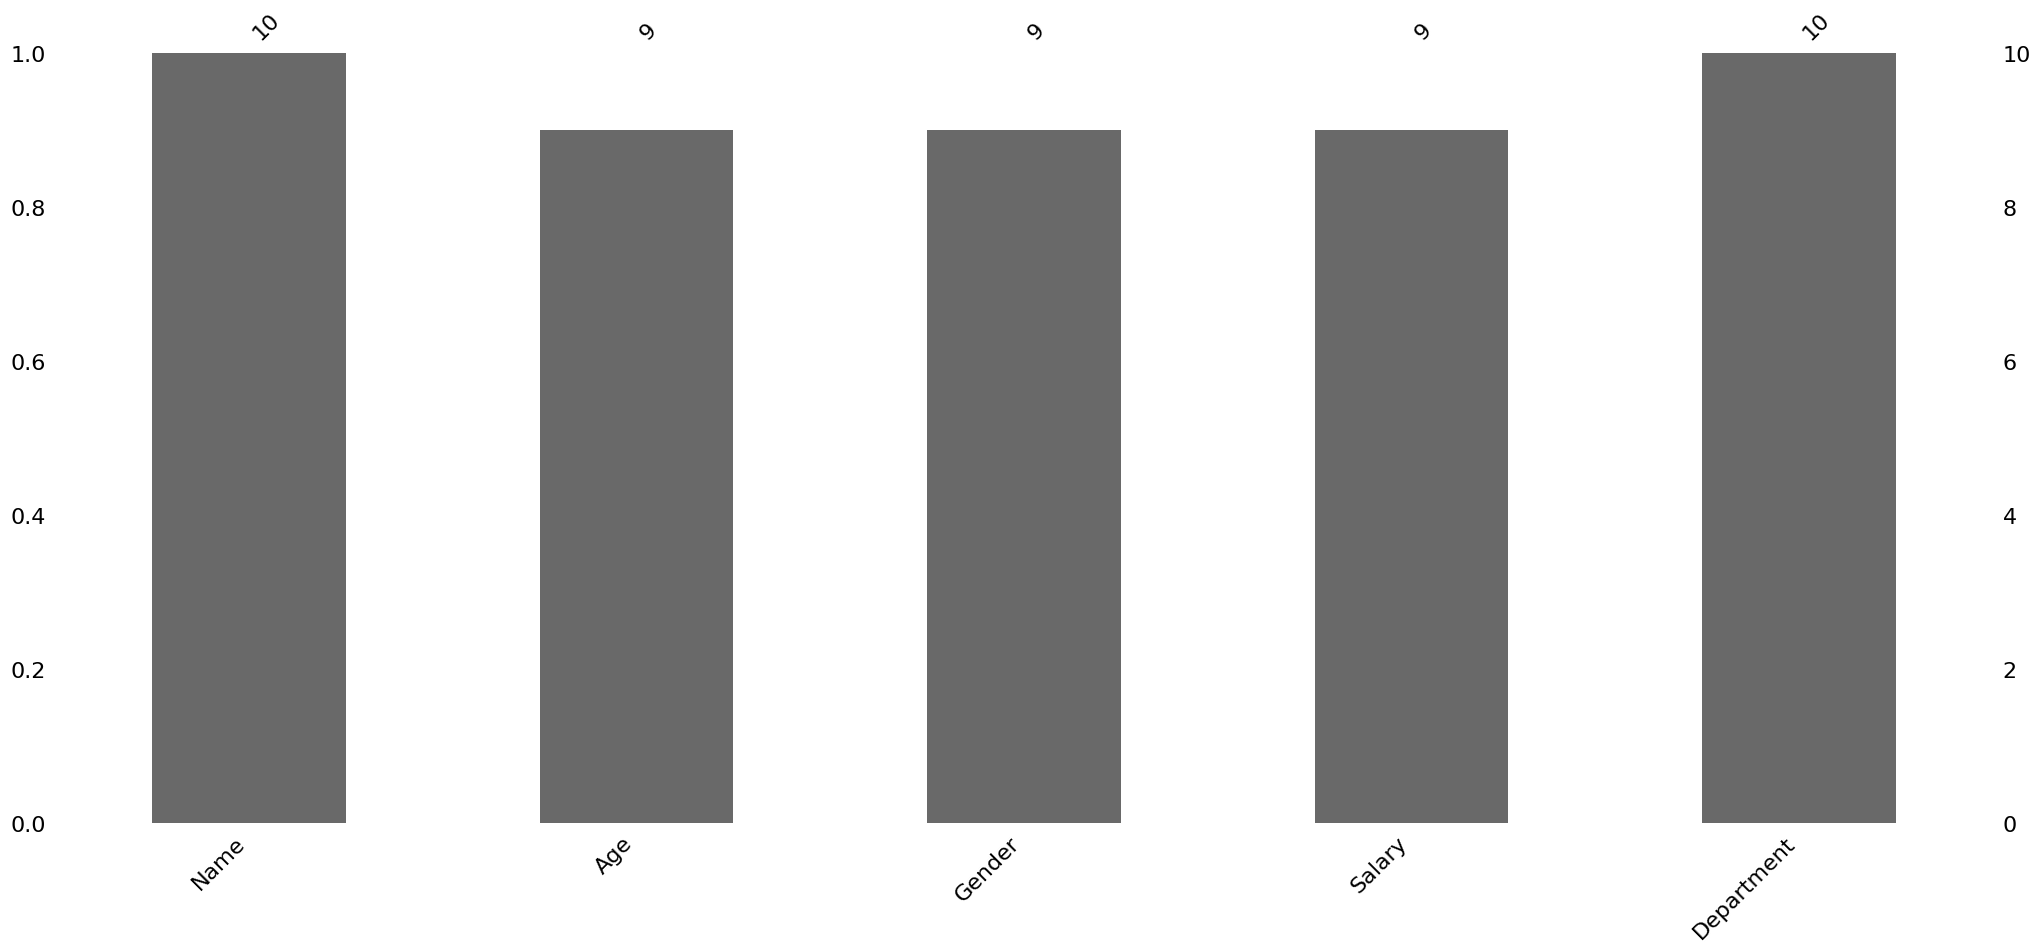

In [10]:
!pip install missingno
import missingno as msno
msno.bar(df)

**using the matrix where exactly value is missing**

<Axes: >

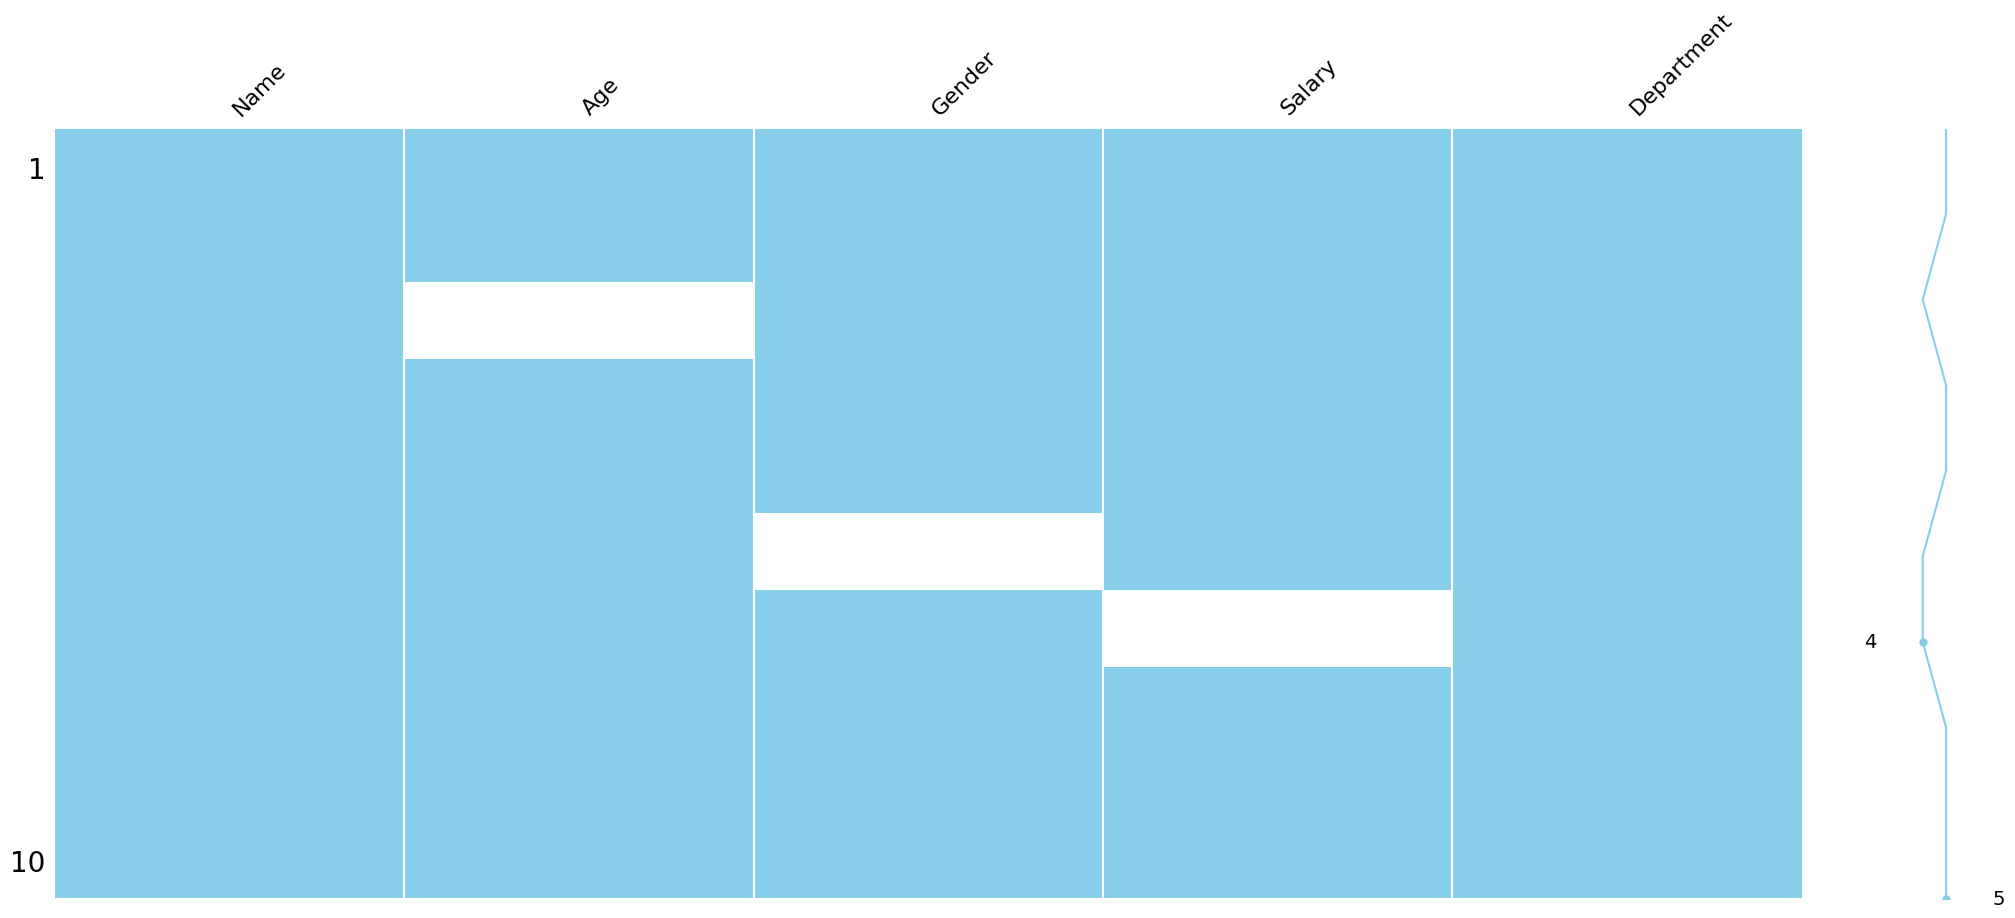

In [11]:
import matplotlib.colors as mcolors
msno.matrix(df, color=mcolors.to_rgb("skyblue"))

<Axes: >

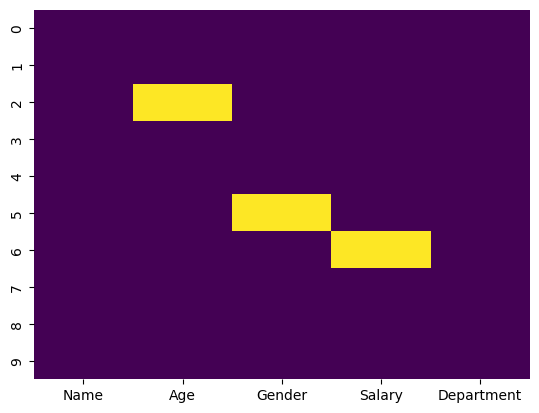

In [12]:
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

Handling Missing values
*   mean -continuous values -no outlier -normal (if there is no skewed but that is necessary means we can go
1.   discrete -countable, not mention in decimal , only whole values
2.   continuous- decimal , fraction

*  median- Skewed data-discrete -outlier(ceo example)
*  mode -categorical

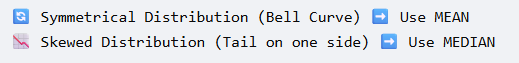



In [13]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Salary'].fillna(df['Salary'].mean(),inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df.isnull().sum()

/tmp/ipykernel_1678/2724753584.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/tmp/ipykernel_1678/2724753584.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,0
Name,0
Age,0
Gender,0
Salary,0
Department,0


major differnce between Imputer and fillna
**Simple Imputer is 2D method so we using the Data Frame**

In [14]:
from sklearn.impute import SimpleImputer
imp1=SimpleImputer(strategy='median')
df[['Age','Salary']]=imp1.fit_transform(df[['Age','Salary']])
df

,Name,Age,Gender,Salary,Department
0,Alice,25.000000,F,50000.000000,HR
1,Bob,30.000000,M,60000.000000,Finance
2,Charlie,39.555556,M,55000.000000,IT
3,David,40.000000,M,58000.000000,HR
4,Eve,22.000000,F,52000.000000,IT
5,Frank,35.000000,M,61000.000000,Finance
6,Grace,120.000000,F,57777.777778,Finance
7,Henry,28.000000,M,59000.000000,HR
8,Ivy,29.000000,F,63000.000000,IT
9,Jack,27.000000,M,62000.000000,Finance


In [15]:
imp2=SimpleImputer(strategy='most_frequent')
df[['Gender']]=imp2.fit_transform(df[['Gender']])
df1

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


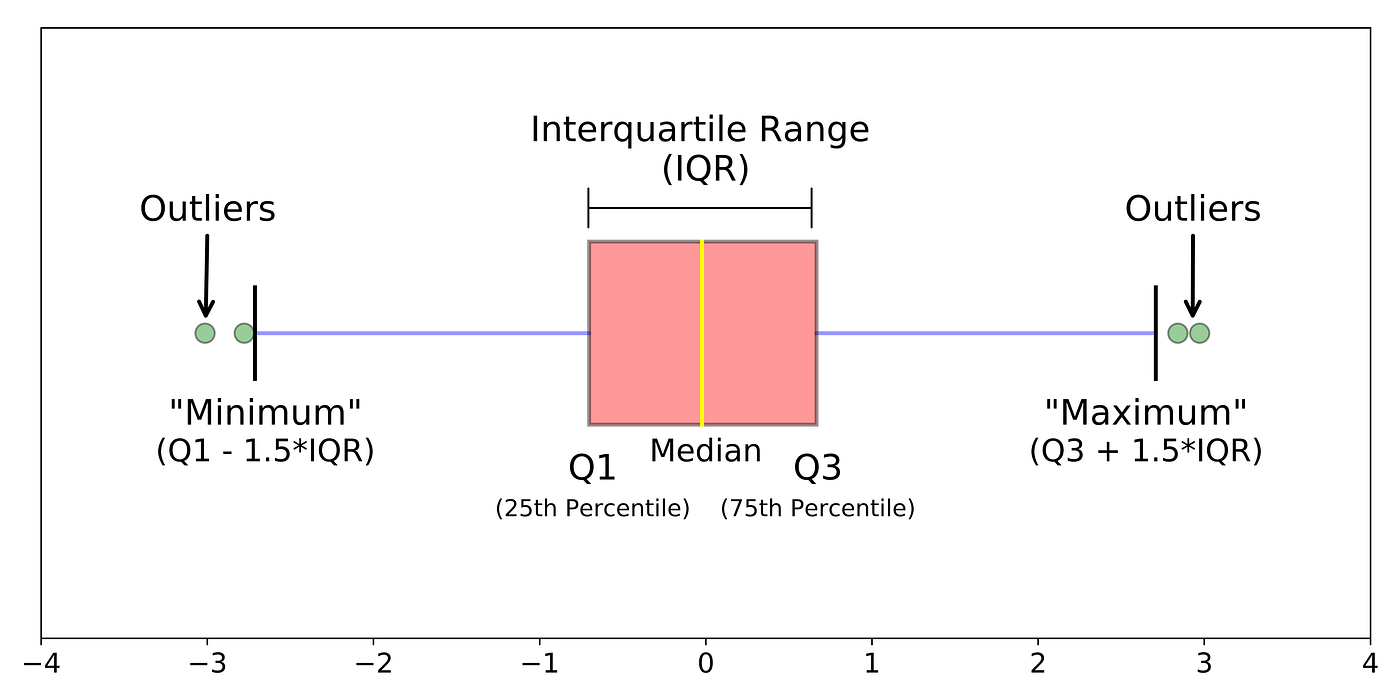

outlier using Boxplot
*   
*   List item



<Axes: ylabel='Age'>

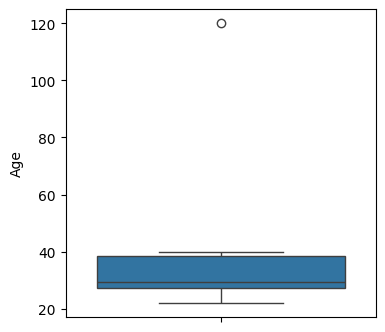

In [16]:
plt.figure(figsize=(4,4))
sns.boxplot(df['Age'])


<Axes: ylabel='Salary'>

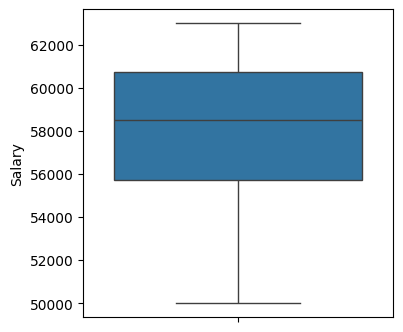

In [17]:
plt.figure(figsize=(4,4))
sns.boxplot(df['Salary'])

In [36]:
df4=pd.read_csv('/content/drive/MyDrive/DATASET /preprocessing_dataset.csv')

In [37]:
q1=df4['Age'].quantile(0.25)
q3=df4['Age'].quantile(0.75)
IQR=q3-q1
lower= q1-1.5*IQR
upper =q3+1.5*IQR
outlier=df4[(df4['Age']<lower) | (df4['Age']>upper)]
outlier
no_outlier=df4[(df4['Age']>lower) | (df4['Age']<upper)]
no_outlier

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [38]:
from scipy.stats import zscore
z_score=zscore(df[['Age','Salary']]) #common rule :z>3
df4[np.abs(z_score)>2.5]

/tmp/ipykernel_1678/3954342794.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score=zscore(df[['Age','Salary']]) #common rule :z>3


,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,NaN,Finance


In [39]:
from sklearn.ensemble import IsolationForest
iso=IsolationForest(contamination=0.1)
df4['outlier']=iso.fit_predict(df4[['Age','Salary']])
df4[df4['outlier']==-1] #after this aply the boxplot


,Name,Age,Gender,Salary,Department,outlier
0,Alice,25.0,F,50000.0,HR,-1


# **outlier**

# **Winsorization**

Winsorization is a statistical technique used to reduce the effect of outliers without deleting data.
Instead of removing extreme values,
you replace them with less extreme values.
> Outliers distort:
-Mean,Standard deviation,Regression,Distance-based ML algorithms,Scaling'

Winsorization reduces this distortion.


> Percentile Winsorization

Example:

Lower limit = 5th percentile
Upper limit = 95th percentile

Rules:

Values below 5% → replaced by 5th percentile value
Values above 95% → replaced by 95th percentile value



In [40]:
df4.isnull().sum()

,0
Name,0
Age,1
Gender,1
Salary,1
Department,0
outlier,0


In [44]:
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='most_frequent')
imp1=SimpleImputer(strategy='median')
df4[['Age','Salary']]=imp1.fit_transform(df4[['Age','Salary']])
df4[['Gender']]=im.fit_transform(df4[['Gender']])


In [48]:
from scipy.stats.mstats import winsorize
df4['Age']=winsorize(df4['Age'],limits=[0.2,0.2]) # limits[first 0.05, last 0.95]
df4['Salary']=winsorize(df4['Salary'],limits=[0.2,0.2])
#df4['Gender']=winsorize(df4['Gender'],limits=[0.05,0.05]) not working
#small datset means limit should be like 0.2to start
#large datset means limit should be lower
df4.isnull().sum()
df4

,Name,Age,Gender,Salary,Department,outlier
0,Alice,27.0,F,55000.0,HR,-1
1,Bob,30.0,M,60000.0,Finance,1
2,Charlie,29.0,M,55000.0,IT,1
3,David,35.0,M,58000.0,HR,1
4,Eve,27.0,F,55000.0,IT,1
5,Frank,35.0,M,61000.0,Finance,1
6,Grace,35.0,F,59000.0,Finance,1
7,Henry,28.0,M,59000.0,HR,1
8,Ivy,29.0,F,61000.0,IT,1
9,Jack,27.0,M,61000.0,Finance,1


# **Log Transform**


> Log Transformation is a preprocessing technique used to reduce skewness and compress large numerical values by applying a logarithmic function to the data.



In [54]:
df5=pd.read_csv('/content/drive/MyDrive/DATASET /preprocessing_dataset.csv')
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='most_frequent')
imp1=SimpleImputer(strategy='median')
df5[['Age','Salary']]=imp1.fit_transform(df5[['Age','Salary']])
df5[['Gender']]=im.fit_transform(df5[['Gender']])

df5[['Age','Salary']]=np.log(df5[['Age','Salary']])
df5
#this is for positive value handling 1 to inf
df5[['Age','Salary']]=np.log1p(df5[['Age','Salary']])
df5

,Name,Age,Gender,Salary,Department
0,Alice,3.258097,F,10.819798,HR
1,Bob,3.433987,M,11.002117,Finance
2,Charlie,3.401197,M,10.915107,IT
3,David,3.713572,M,10.968216,HR
4,Eve,3.135494,F,10.859018,IT
5,Frank,3.583519,M,11.018646,Finance
6,Grace,4.795791,F,10.985310,Finance
7,Henry,3.367296,M,10.985310,HR
8,Ivy,3.401197,F,11.050906,IT
9,Jack,3.332205,M,11.034906,Finance


# **Power Transform**

> Log Transform- Only compresses.

>Power Transform - Learns the best transformation mathematically using: λ

method type
1.  yeo-johnson-(dataset have  the negative  and zero)
2.   box-cox -(doesn't have)

***Problems:***

unstable variance
extreme influence
poor linear modeling






In [57]:
d6=pd.read_csv('/content/drive/MyDrive/DATASET /preprocessing_dataset.csv')
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='most_frequent')
imp1=SimpleImputer(strategy='median')
d6[['Age','Salary']]=imp1.fit_transform(d6[['Age','Salary']])
d6[['Gender']]=im.fit_transform(d6[['Gender']])
d6


,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,29.0,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,M,61000.0,Finance
6,Grace,120.0,F,59000.0,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


# **method - yeo-johnson**

In [60]:
from sklearn.preprocessing import PowerTransformer
pt1=PowerTransformer(method='yeo-johnson')
d6[['Age','Salary']]=pt1.fit_transform(d6[['Age','Salary']])
d6

,Name,Age,Gender,Salary,Department
0,Alice,-0.911499,F,-1.646982,HR
1,Bob,0.043753,M,0.417949,Finance
2,Charlie,-0.108436,M,-0.881385,IT
3,David,0.989428,M,-0.181522,HR
4,Eve,-1.822158,F,-1.390657,IT
5,Frank,0.618211,M,0.764606,Finance
6,Grace,2.041784,F,0.103409,Finance
7,Henry,-0.277302,M,0.103409,HR
8,Ivy,-0.108436,F,1.565124,IT
9,Jack,-0.465344,M,1.146049,Finance


# **BOX-COX**

In [61]:
d7=pd.read_csv('/content/drive/MyDrive/DATASET /preprocessing_dataset.csv')
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='most_frequent')
imp1=SimpleImputer(strategy='median')
d7[['Age','Salary']]=imp1.fit_transform(d7[['Age','Salary']])
d7[['Gender']]=im.fit_transform(d7[['Gender']])
d7

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,29.0,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT
5,Frank,35.0,M,61000.0,Finance
6,Grace,120.0,F,59000.0,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [62]:
from sklearn.preprocessing import PowerTransformer
pt1=PowerTransformer(method='box-cox')
d7[['Age','Salary']]=pt1.fit_transform(d7[['Age','Salary']])
d7

,Name,Age,Gender,Salary,Department
0,Alice,-0.910604,F,-1.646983,HR
1,Bob,0.045799,M,0.417949,Finance
2,Charlie,-0.106151,M,-0.881385,IT
3,David,0.987200,M,-0.181521,HR
4,Eve,-1.828669,F,-1.390657,IT
5,Frank,0.618128,M,0.764606,Finance
6,Grace,2.038488,F,0.103409,Finance
7,Henry,-0.274931,M,0.103409,HR
8,Ivy,-0.106151,F,1.565124,IT
9,Jack,-0.463109,M,1.146049,Finance


**StandardScaler**

In [64]:
from sklearn.preprocessing import StandardScaler
d8=pd.read_csv('/content/drive/MyDrive/DATASET /preprocessing_dataset.csv')
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='most_frequent')
imp1=SimpleImputer(strategy='median')
d8[['Age','Salary']]=imp1.fit_transform(d8[['Age','Salary']])
d8[['Gender']]=im.fit_transform(d8[['Gender']])

scaler = StandardScaler()

d8[['Age','Salary']] = scaler.fit_transform(
    d8[['Age','Salary']]
)
d8

,Name,Age,Gender,Salary,Department
0,Alice,-0.489487,F,-1.945435,HR
1,Bob,-0.308196,M,0.517141,Finance
2,Charlie,-0.344454,M,-0.714147,IT
3,David,0.054387,M,0.024626,HR
4,Eve,-0.598262,F,-1.452920,IT
5,Frank,-0.126904,M,0.763399,Finance
6,Grace,2.955052,F,0.270883,Finance
7,Henry,-0.380712,M,0.270883,HR
8,Ivy,-0.344454,F,1.255914,IT
9,Jack,-0.416971,M,1.009656,Finance


| StandardScaler                       | MinMaxScaler                  |
| ------------------------------------ | ----------------------------- |
| Converts data around mean 0          | Converts data between 0 and 1 |
| Uses Mean & SD                       | Uses Min & Max                |
| Can produce negative values          | Usually no negative values    |
| Best for normal distribution         | Best for bounded range        |
| Less affected by small range changes | Very sensitive to outliers    |


In [66]:
from sklearn.preprocessing import MinMaxScaler
d9=pd.read_csv('/content/drive/MyDrive/DATASET /preprocessing_dataset.csv')
from sklearn.impute import SimpleImputer
im=SimpleImputer(strategy='most_frequent')
imp1=SimpleImputer(strategy='median')
d9[['Age','Salary']]=imp1.fit_transform(d9[['Age','Salary']])
d9[['Gender']]=im.fit_transform(d9[['Gender']])

scaler =MinMaxScaler()

d9[['Age','Salary']] = scaler.fit_transform(
    d9[['Age','Salary']]
)
d9

,Name,Age,Gender,Salary,Department
0,Alice,0.030612,F,0.000000,HR
1,Bob,0.081633,M,0.769231,Finance
2,Charlie,0.071429,M,0.384615,IT
3,David,0.183673,M,0.615385,HR
4,Eve,0.000000,F,0.153846,IT
5,Frank,0.132653,M,0.846154,Finance
6,Grace,1.000000,F,0.692308,Finance
7,Henry,0.061224,M,0.692308,HR
8,Ivy,0.071429,F,1.000000,IT
9,Jack,0.051020,M,0.923077,Finance
